Gain_k_0.1 -> Average Cross-Track Error: 7.735m, RMSE: 8.872m
Gain_k_0.5 -> Average Cross-Track Error: 2.673m, RMSE: 5.182m
Gain_k_1.5 -> Average Cross-Track Error: 1.790m, RMSE: 4.590m
Gain_k_2.0 -> Average Cross-Track Error: 1.710m, RMSE: 4.541m


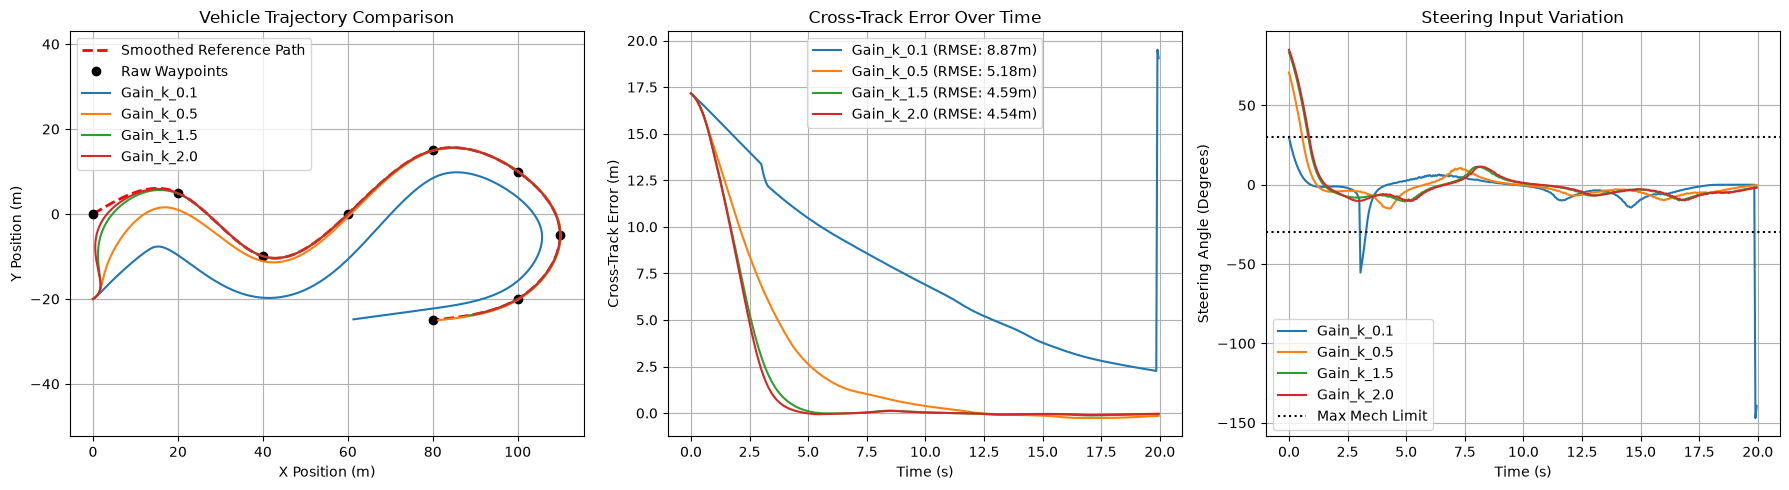

In [9]:
#!pip install scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# SIMULATION CONFIGURATION (Global Variables)
# ==========================================
sa = 30           # Steering angle limit in degrees
wb = 2            # Wheelbase in meters
k_gain = 0.5      # Default position gain
ks_gain = 1.0     # Default softening gain
v_target = 10.0   # Target speed (m/s)
lat_offset = 20.0  # Initial lateral offset from path (meters)
time_limit = 20.0 # Simulation run time (seconds)
dt = 0.05         # Physics time step (seconds)
gains_to_test = [0.1, 0.5, 1.5, 2.0]  # Different k gains for experimentation

# ==========================================
# VEHICLE & CONTROLLER CLASSES
# ==========================================
class KinematicBicycleModel:
    def __init__(self, x=0.0, y=0.0, yaw=0.0, v=0.0, L=2.0): # Use a standard fallback value here
        self.x = x
        self.y = y
        self.yaw = yaw
        self.v = v
        self.L = L  # This will be overridden explicitly below

    def update(self, a, delta, dt, max_steer_deg): # Explicitly pass the steering limit variable
        delta = np.clip(delta, -np.radians(max_steer_deg), np.radians(max_steer_deg))
        
        self.x += self.v * np.cos(self.yaw) * dt
        self.y += self.v * np.sin(self.yaw) * dt
        self.yaw += (self.v / self.L) * np.tan(delta) * dt
        self.v += a * dt

class StanleyController:
    def __init__(self, k=0.5, ks=1.0): # Clear global variables here too
        self.k = k
        self.ks = ks

    def compute_steering(self, vehicle, path_x, path_y, path_yaw):
        # 1. Find the closest point on the path to the FRONT axle
        fx = vehicle.x + vehicle.L * np.cos(vehicle.yaw)
        fy = vehicle.y + vehicle.L * np.sin(vehicle.yaw)
        
        dx = [fx - x for x in path_x]
        dy = [fy - y for y in path_y]
        distances = np.hypot(dx, dy)
        target_idx = np.argmin(distances)

        # 2. Correct Cross-Track Error calculation (Using 2D Cross Product)
        dx_front = fx - path_x[target_idx]
        dy_front = fy - path_y[target_idx]
        
        path_vec_x = np.cos(path_yaw[target_idx])
        path_vec_y = np.sin(path_yaw[target_idx])
        
        error_front_axle = dx_front * path_vec_y - dy_front * path_vec_x

        # 3. Correct Heading Error (Path Yaw minus Vehicle Yaw)
        yaw_error = path_yaw[target_idx] - vehicle.yaw
        yaw_error = np.arctan2(np.sin(yaw_error), np.cos(yaw_error))

        # 4. Stanley Control Law
        crosstrack_steering = np.arctan2(self.k * error_front_axle, vehicle.v + self.ks)
        delta = yaw_error + crosstrack_steering
        
        return delta, error_front_axle

# ==========================================
# SIMULATION CORE ENGINE
# ==========================================
def run_simulation(path_x, path_y, path_yaw, k_param, ks_param):
    # Pass 'wb' explicitly here! Now changing 'wb' at the top will work instantly.
    vehicle = KinematicBicycleModel(x=path_x[0], y=path_y[0] - lat_offset, yaw=path_yaw[0], v=2.0, L=wb)
    controller = StanleyController(k=k_param, ks=ks_param)
    
    time = 0.0
    logs = []

    while time < time_limit: # Uses time_limit from the top
        a = 0.5 * (v_target - vehicle.v) # Uses v_target from the top
        
        delta, cte = controller.compute_steering(vehicle, path_x, path_y, path_yaw)
        
        logs.append({
            'time': time, 'x': vehicle.x, 'y': vehicle.y, 
            'yaw': vehicle.yaw, 'v': vehicle.v, 'cte': cte, 'delta': delta
        })
        
        # Pass 'sa' and 'dt' explicitly into the physics update step
        vehicle.update(a, delta, dt, max_steer_deg=sa)
        time += dt
        
    return pd.DataFrame(logs)

# ==========================================
# EXECUTION & EXPERIMENTATION
# ==========================================

# 1. Generate the shared Reference S-Curve Path
#path_x = np.linspace(0, 100, 1000)
#path_y = np.sin(path_x / 10.0) * 2.0  
#path_yaw = np.gradient(path_y, path_x)

from scipy.interpolate import CubicSpline

# 1. Define raw track waypoints (rough layout of your realistic track)
# Imagine a custom track with an S-curve followed by a sharp hairpin turn
waypoints_x = [0.0, 20.0,  40.0, 60.0,  80.0, 100.0, 110.0, 100.0, 80.0]
waypoints_y = [0.0,  5.0, -10.0,  0.0,  15.0,  10.0,  -5.0, -20.0, -25.0]

# Generate a continuous independent variable (parametric mapping based on waypoint index)
t_waypoints = np.arange(len(waypoints_x))

# Fit separate cubic splines for X and Y coordinates against the parameter 't'
spline_x = CubicSpline(t_waypoints, waypoints_x, bc_type='natural')
spline_y = CubicSpline(t_waypoints, waypoints_y, bc_type='natural')

# Generate a dense array of points along the spline to make the path smooth
# 1000 points ensures high fidelity tracking points for the front axle search
t_fine = np.linspace(0, len(waypoints_x) - 1, 1000)
path_x = spline_x(t_fine)
path_y = spline_y(t_fine)

# 2. Calculate smooth Heading Angles (path_yaw) along the spline
# We take the first derivatives (tangents) of X and Y with respect to our fine timeline
dx_dt = spline_x(t_fine, 1)
dy_dt = spline_y(t_fine, 1)

# arctan2 calculates the exact angle of the path vector relative to the global grid
path_yaw = np.arctan2(dy_dt, dx_dt)

# 2. Define our multi-run batch configuration
results = {}

# Execute batch runs
for g in gains_to_test:
    run_id = f"Gain_k_{g}"
    results[run_id] = run_simulation(path_x, path_y, path_yaw, k_param=g, ks_param=ks_gain)

# 3. Data Processing and Comparisons (3-Panel Layout)
plt.figure(figsize=(18, 5)) # Made the window wider to fit three plots comfortably

# Subplot 1: Visual Map Comparison
plt.subplot(1, 3, 1)
# Plot the continuous smooth reference path generated by the spline
plt.plot(path_x, path_y, 'r--', linewidth=2, label='Smoothed Reference Path')
# Plot the raw milestone waypoints as black dots to see the track skeleton
plt.plot(waypoints_x, waypoints_y, 'ko', markersize=6, label='Raw Waypoints')

for run_id, df in results.items():
    plt.plot(df['x'], df['y'], label=f"{run_id}")

plt.title('Vehicle Trajectory Comparison')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.legend()
plt.grid(True)
plt.axis('equal') # CRITICAL: Keeps 1 meter on X equal to 1 meter on Y so the track looks real

# Subplot 2: Error Analysis Over Time
plt.subplot(1, 3, 2)
for run_id, df in results.items():
    rmse = np.sqrt((df['cte'] ** 2).mean())
    print(f"{run_id} -> Average Cross-Track Error: {df['cte'].abs().mean():.3f}m, RMSE: {rmse:.3f}m")
    plt.plot(df['time'], df['cte'], label=f"{run_id} (RMSE: {rmse:.2f}m)")
plt.xlabel('Time (s)')
plt.ylabel('Cross-Track Error (m)')
plt.legend()
plt.title('Cross-Track Error Over Time')
plt.grid(True)

# Subplot 3: Steering Angle Variation
plt.subplot(1, 3, 3)
for run_id, df in results.items():
    # Convert delta from radians to degrees for readability
    steering_deg = np.degrees(df['delta'])
    plt.plot(df['time'], steering_deg, label=f"{run_id}")

# Plot a horizontal line showing our physical hardware steering limit
plt.axhline(y=sa, color='k', linestyle=':', label='Max Mech Limit')
plt.axhline(y=-sa, color='k', linestyle=':')

plt.xlabel('Time (s)')
plt.ylabel('Steering Angle (Degrees)')
plt.title('Steering Input Variation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()